# Notebook 1: Data Preprocessing — Bearing-1 (Original)

**Research**: Bearing RUL Prediction under Shaft Misalignment with Explainable AI  
**Bearing**: UCP 204 (Run-to-Failure, 108 hours)  
**Pipeline**: Raw Parquet → Vectorized Feature Extraction → CUSUM TCP Detection → BHI Labeling → Processed Parquet

---

## 1. Global Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
# ── Path Configuration ──────────────────────────────────────────────────────
ROOT_DIR       = "D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI"
BEARING_NAME   = "bearing_1"
INPUT_PARQUET  = os.path.join(ROOT_DIR, f"{BEARING_NAME}_full.parquet")
OUTPUT_PARQUET = os.path.join(ROOT_DIR, BEARING_NAME, "processed_bearing1.parquet")

# ── Signal Parameters ────────────────────────────────────────────────────────
SAMPLING_RATE    = 2560          # Hz
SEGMENT_SECONDS  = 60            # seconds per segment
SAMPLES_PER_SEG  = SAMPLING_RATE * SEGMENT_SECONDS  # 153,600 samples
TOTAL_DURATION_H = 108           # hours
N_SEGMENTS       = TOTAL_DURATION_H * 60             # 6,480 segments
RPM              = 3000
FR               = RPM / 60     # rotation frequency = 50 

# ── Degradation & CUSUM Parameters ──────────────────────────────────────────
DEGRADATION_TYPE = 'linear'      # 'linear' or 'sigmoid'
TARGET_TCP_AXIS  = 'y'           # axis used for CUSUM: 'x', 'y', or 'z'
CUSUM_K          = 1.0           # allowance parameter (half of expected shift in std units)
CUSUM_H          = 8.0           # decision threshold (std units)
EMA_SPAN         = 20            # EMA span in segments
CUSUM_BASELINE_FRAC = 0.50       # use first 20% of segments as reference (healthy phase)

# ── UCP 204 Bearing Defect Frequency Configuration ───────────────────────────
D_PITCH   = 33.5   # Pitch circle diameter (mm)
D_BALL    = 7.94   # Ball diameter (mm)
Z_BALLS   = 8      # Number of balls
ALPHA_DEG = 0      # Contact angle (degrees)
ALPHA_RAD = np.deg2rad(ALPHA_DEG)
DEFECT_BW = 5.0    # Bandwidth (±Hz) around each defect frequency

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.4,
    'legend.fontsize': 9,
})

print(f"Segment size     : {SAMPLES_PER_SEG:,} samples ({SEGMENT_SECONDS} s)")
print(f"Total segments   : {N_SEGMENTS:,}")
print(f"Total raw rows   : {N_SEGMENTS * SAMPLES_PER_SEG:,}")
print(f"Rotation freq    : {FR} Hz")

<>:14: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\P'
C:\Users\HP\AppData\Local\Temp\ipykernel_24600\4087041933.py:14: SyntaxWarning: invalid escape sequence '\P'
  ROOT_DIR       = "D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI"


Segment size     : 153,600 samples (60 s)
Total segments   : 6,480
Total raw rows   : 995,328,000
Rotation freq    : 50.0 Hz


In [2]:
print(INPUT_PARQUET, OUTPUT_PARQUET)

D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1_full.parquet D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1\processed_bearing1.parquet


## 2. Bearing Defect Frequency Computation

In [3]:
def compute_defect_frequencies(fr, D, d, Z, alpha):
    """Compute BPFO, BPFI, BSF using standard bearing kinematic equations."""
    ratio = (d / D) * np.cos(alpha)
    BPFO  = (Z / 2) * fr * (1 - ratio)
    BPFI  = (Z / 2) * fr * (1 + ratio)
    BSF   = (D / (2 * d)) * fr * (1 - ratio ** 2)
    return BPFO, BPFI, BSF

BPFO, BPFI, BSF = compute_defect_frequencies(FR, D_PITCH, D_BALL, Z_BALLS, ALPHA_RAD)

print(f"BPFO : {BPFO:.2f} Hz")
print(f"BPFI : {BPFI:.2f} Hz")
print(f"BSF  : {BSF:.2f} Hz")

BPFO : 152.60 Hz
BPFI : 247.40 Hz
BSF  : 99.55 Hz


## 3. Load Raw Data

In [4]:
import pyarrow.dataset as ds

print(f"Preparing lazy batch processing for: {INPUT_PARQUET}")

# Use pyarrow.dataset to support both single files and partitioned directories natively
dataset = ds.dataset(INPUT_PARQUET, format="parquet")
schema_names = dataset.schema.names

col_x = [c for c in schema_names if c.strip().lower() == 'x'][0]
col_y = [c for c in schema_names if c.strip().lower() == 'y'][0]
col_z = [c for c in schema_names if c.strip().lower() == 'z'][0]
target_cols = [col_x, col_y, col_z]

print(f"Columns selected for processing: {target_cols}")

Preparing lazy batch processing for: D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1_full.parquet
Columns selected for processing: ['X', 'Y', 'Z']


## 4. Vectorized Feature Extraction

The raw array is reshaped to `(N_segments, SAMPLES_PER_SEG, 3)` so that all statistical operations are applied along `axis=1` without any Python-level loop over segments.

### 4.1 Reshape Raw Array

In [5]:
# Skipping full array reshaping to prevent OOM (Out Of Memory).
# The data will be read and processed in chunks instead of loading entirely into RAM.

### 4.2 Time-Domain Features (Vectorized)

In [6]:
def extract_time_domain_features(data):
    """
    Compute 11 time-domain statistical features for all segments and all axes simultaneously.
    Input  : data — ndarray shape (N_segments, N_samples, N_axes)
    Output : dict of ndarrays each shape (N_segments, N_axes)
    """
    mean_val     = np.mean(data, axis=1)
    std_val      = np.std(data, axis=1, ddof=1)
    rms          = np.sqrt(np.mean(data ** 2, axis=1))
    peak         = np.max(np.abs(data), axis=1)
    p2p          = np.max(data, axis=1) - np.min(data, axis=1)
    mean_abs     = np.mean(np.abs(data), axis=1)
    mean_sq_abs  = np.mean(np.sqrt(np.abs(data)), axis=1)

    N, S, A = data.shape
    skewness = np.zeros((N, A), dtype=np.float32)
    kurtosis = np.zeros((N, A), dtype=np.float32)
    
    for a in range(A):
        skewness[:, a] = stats.skew(data[:, :, a], axis=1)
        kurtosis[:, a] = stats.kurtosis(data[:, :, a], axis=1)

    peak_factor      = peak / (rms + 1e-12)
    clearance_factor = peak / (mean_sq_abs ** 2 + 1e-12)
    shape_factor     = rms / (mean_abs + 1e-12)
    impulse_factor   = peak / (mean_abs + 1e-12)

    return {
        'td_mean'            : mean_val,
        'td_std'             : std_val,
        'td_rms'             : rms,
        'td_peak_value'      : peak,
        'td_p2p'             : p2p,
        'td_skewness'        : skewness,
        'td_kurtosis'        : kurtosis,
        'td_peak_factor'     : peak_factor,
        'td_clearance_factor': clearance_factor,
        'td_shape_factor'    : shape_factor,
        'td_impulse_factor'  : impulse_factor,
    }

### 4.3 Frequency-Domain Features (Vectorized FFT)

In [7]:
def extract_frequency_domain_features(data, fs, defect_freqs, bw):
    """
    Compute FFT-based features and defect-frequency band energies.
    Input  : data — ndarray (N_segments, N_samples, N_axes)
    Output : dict of ndarrays each shape (N_segments, N_axes)
    """
    N, S, A = data.shape
    freqs   = np.fft.rfftfreq(S, d=1.0 / fs)
    fft_amp = np.abs(np.fft.rfft(data, axis=1)) / S

    amp_sum  = np.sum(fft_amp, axis=1, keepdims=True) + 1e-12
    freq_mat = freqs[np.newaxis, :, np.newaxis]

    mean_freq    = np.sum(freq_mat * fft_amp, axis=1) / amp_sum.squeeze(1)
    centroid     = mean_freq.copy()
    fft_p2p      = np.max(fft_amp, axis=1) - np.min(fft_amp, axis=1)
    spectral_eng = np.sum(fft_amp ** 2, axis=1)

    def band_energy(center):
        mask = (freqs >= center - bw) & (freqs <= center + bw)
        return np.sum(fft_amp[:, mask, :] ** 2, axis=1)

    return {
        'fd_mean_freq'      : mean_freq,
        'fd_centroid_freq'  : centroid,
        'fd_fft_p2p'        : fft_p2p,
        'fd_spectral_energy': spectral_eng,
        'fd_bpfo_energy'    : band_energy(defect_freqs['BPFO']),
        'fd_bpfi_energy'    : band_energy(defect_freqs['BPFI']),
        'fd_bsf_energy'     : band_energy(defect_freqs['BSF']),
    }, fft_amp, freqs

defect_freqs = {'BPFO': BPFO, 'BPFI': BPFI, 'BSF': BSF}

### 4.4 Assemble Feature DataFrame

In [8]:
print("Starting chunked processing for feature extraction...")
AXES = ['x', 'y', 'z']
td_names = ['td_mean', 'td_std', 'td_rms', 'td_peak_value', 'td_p2p', 'td_skewness', 'td_kurtosis', 'td_peak_factor', 'td_clearance_factor', 'td_shape_factor', 'td_impulse_factor']
fd_names = ['fd_mean_freq', 'fd_centroid_freq', 'fd_fft_p2p', 'fd_spectral_energy', 'fd_bpfo_energy', 'fd_bpfi_energy', 'fd_bsf_energy']

td_list = {k: [] for k in td_names}
fd_list = {k: [] for k in fd_names}

seg_count = 0
buffer_rows = np.empty((SAMPLES_PER_SEG, 3), dtype=np.float32)
buffer_idx = 0

# Scan dataset in batches securely
for batch in dataset.to_batches(columns=target_cols, batch_size=SAMPLES_PER_SEG):
    if seg_count >= N_SEGMENTS: 
        break
        
    chunk = batch.to_pandas().values.astype(np.float32)
    chunk_rows = chunk.shape[0]
    pos = 0
    
    while pos < chunk_rows and seg_count < N_SEGMENTS:
        take = min(SAMPLES_PER_SEG - buffer_idx, chunk_rows - pos)
        buffer_rows[buffer_idx:buffer_idx+take] = chunk[pos:pos+take]
        buffer_idx += take
        pos += take
        
        if buffer_idx == SAMPLES_PER_SEG:
            segment_data = buffer_rows.reshape(1, SAMPLES_PER_SEG, 3)
            
            td = extract_time_domain_features(segment_data)
            fd, _, _ = extract_frequency_domain_features(segment_data, SAMPLING_RATE, defect_freqs, DEFECT_BW)
            
            for k in td_names: td_list[k].append(td[k][0])
            for k in fd_names: fd_list[k].append(fd[k][0])
                
            seg_count += 1
            buffer_idx = 0
            
            if seg_count % 1500 == 0: 
                print(f"Processed {seg_count}/{N_SEGMENTS} segments...")

print("Chunked processing done. Assembling DataFrame...")
segment_time = np.arange(seg_count) * SEGMENT_SECONDS
feature_dict = {'segment': np.arange(seg_count), 'time_s': segment_time, 'time_min': segment_time / 60}

for feat_name, lst in td_list.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES): 
        feature_dict[f"{feat_name}_{ax}"] = arr[:, i].astype(np.float64)

for feat_name, lst in fd_list.items():
    arr = np.array(lst)
    for i, ax in enumerate(AXES): 
        feature_dict[f"{feat_name}_{ax}"] = arr[:, i].astype(np.float64)

df_features = pd.DataFrame(feature_dict)
print(f"Feature matrix shape: {df_features.shape}")
df_features.head(3)

Starting chunked processing for feature extraction...
Processed 1500/6480 segments...
Processed 3000/6480 segments...
Processed 4500/6480 segments...
Processed 6000/6480 segments...
Chunked processing done. Assembling DataFrame...
Feature matrix shape: (6480, 57)


,segment,time_s,time_min,td_mean_x,td_mean_y,td_mean_z,td_std_x,td_std_y,td_std_z,td_rms_x,...,fd_spectral_energy_z,fd_bpfo_energy_x,fd_bpfo_energy_y,fd_bpfo_energy_z,fd_bpfi_energy_x,fd_bpfi_energy_y,fd_bpfi_energy_z,fd_bsf_energy_x,fd_bsf_energy_y,fd_bsf_energy_z
0,0,0,0.0,-0.000417,-0.000118,0.000226,9.158785,8.302037,4.518920,9.158749,...,10.210547,2.407245,0.196925,0.026671,0.788811,0.068780,0.004573,1.934072,0.045325,0.075030
1,1,60,1.0,0.000416,0.000132,0.000373,9.270805,8.209218,4.510395,9.270774,...,10.171990,2.122995,0.196029,0.025926,0.717751,0.066607,0.004903,1.899441,0.045187,0.076280
2,2,120,2.0,-0.000276,-0.000189,-0.001094,8.907632,8.242053,4.501085,8.907604,...,10.130102,2.031941,0.184605,0.023567,0.702440,0.064541,0.004398,1.740267,0.043407,0.071521


## 5. Smoothing — Exponential Moving Average on RMS

In [9]:
for ax in AXES:
    col = f"td_rms_{ax}"
    df_features[f"rms_ema_{ax}"] = (
        df_features[col].ewm(span=EMA_SPAN, adjust=False).mean()
    )

print("EMA smoothing applied to RMS columns.")
df_features[['segment', 'td_rms_x', 'rms_ema_x', 'td_rms_y', 'rms_ema_y', 'td_rms_z', 'rms_ema_z']].tail(5)

EMA smoothing applied to RMS columns.


,segment,td_rms_x,rms_ema_x,td_rms_y,rms_ema_y,td_rms_z,rms_ema_z
6475,6475,9.061733,8.979570,9.482015,9.231021,4.733415,4.952720
6476,6476,9.722218,9.050298,9.441819,9.251097,4.779492,4.936222
6477,6477,10.037515,9.144319,9.284722,9.254299,4.819719,4.925127
6478,6478,9.628437,9.190425,9.400857,9.268257,4.795513,4.912782
6479,6479,9.033563,9.175486,9.394237,9.280255,4.795966,4.901657


## 6. CUSUM — Change Point Detection

In [10]:
def cusum_detection(series, k=1.0, h=8.0, baseline_frac=0.20):
    """
    One-sided upper CUSUM on a Z-score normalized series.
    Bug fix: mu and sigma are estimated ONLY from the healthy baseline window
    (first baseline_frac fraction of the series) to avoid contamination by failure data.
    Returns S (cumulative sum array) and tcp_index (first threshold-crossing index).
    """
    n_baseline = max(1, int(len(series) * baseline_frac))
    mu    = series[:n_baseline].mean()
    sigma = series[:n_baseline].std(ddof=1)
    z     = (series - mu) / (sigma + 1e-12)

    S = np.zeros(len(z))
    for i in range(1, len(z)):
        S[i] = max(0.0, S[i-1] + z[i] - k)

    crossings = np.where(S > h)[0]
    tcp_index = int(crossings[0]) if len(crossings) > 0 else len(series) - 1
    return S, tcp_index

cusum_col        = f"rms_ema_{TARGET_TCP_AXIS}"
cusum_series     = df_features[cusum_col].values
S_cusum, tcp_idx = cusum_detection(
    cusum_series, k=CUSUM_K, h=CUSUM_H, baseline_frac=CUSUM_BASELINE_FRAC
)

T_cp_segment = tcp_idx
T_cp_min     = df_features.loc[tcp_idx, "time_min"]

print(f"CUSUM baseline window : first {int(len(cusum_series)*CUSUM_BASELINE_FRAC)} segments")
print(f"TCP detected at segment : {T_cp_segment}")
print(f"TCP detected at time    : {T_cp_min:.1f} minutes ({T_cp_min/60:.2f} hours)")


CUSUM baseline window : first 3240 segments
TCP detected at segment : 2381
TCP detected at time    : 2381.0 minutes (39.68 hours)


## 7. BHI Labeling

In [11]:
## 7. BHI Labeling (Time-Based vs Signal-Based)
def compute_bhi(n_segments, tcp_idx, degradation_type='linear', method='time_based', df=None):
    """
    Generate Bearing Health Index label.
    - method='time_based': BHI = 1 saat sehat, lalu turun dari 1 ke 0 setelah TCP.
    - method='signal_based': BHI diturunkan dari fitur fisik (BPFI energy + RMS).
    """
    if method == 'time_based':
        bhi = np.ones(n_segments)
        n_degrade = n_segments - tcp_idx
        t_norm    = np.linspace(0, 1, n_degrade)

        if degradation_type == 'linear':
            bhi[tcp_idx:] = 1 - t_norm
        elif degradation_type == 'sigmoid':
            k_sig = 10
            bhi[tcp_idx:] = 1 - (1 / (1 + np.exp(-k_sig * (t_norm - 0.5))))
            bhi[tcp_idx:] = (bhi[tcp_idx:] - bhi[tcp_idx:].min()) / \
                            (bhi[tcp_idx:].max() - bhi[tcp_idx:].min() + 1e-12)
            bhi[tcp_idx:] = 1 - bhi[tcp_idx:]
        else:
            raise ValueError(f"Unknown degradation_type: {degradation_type}")

        return np.clip(bhi, 0, 1)
        
    elif method == 'signal_based':
        if df is None:
            raise ValueError("DataFrame 'df' wajib diisi untuk method 'signal_based'.")
            
        # Normalisasi fitur fisik ke rentang [0, 1]
        bpfi_norm = (df['fd_bpfi_energy_y'] - df['fd_bpfi_energy_y'].min()) / \
                    (df['fd_bpfi_energy_y'].max() - df['fd_bpfi_energy_y'].min() + 1e-12)
        rms_norm  = (df['td_rms_y'] - df['td_rms_y'].min()) / \
                    (df['td_rms_y'].max() - df['td_rms_y'].min() + 1e-12)

        # Composite Health Index (bobot 60% BPFI, 40% RMS)
        # Semakin tinggi energi BPFI/RMS, maka nilai Health Index semakin rendah (mendekati 0)
        hi_signal = 1 - (0.6 * bpfi_norm + 0.4 * rms_norm)
        
        return hi_signal.clip(0, 1).values
    else:
        raise ValueError(f"Unknown method: {method}. Pilih 'time_based' atau 'signal_based'.")

# ==============================================================================
# KONFIGURASI DAN PEMANGGILAN BHI
# ==============================================================================
# GANTI VARIABEL DI BAWAH INI SESUAI KEBUTUHAN: 'time_based' atau 'signal_based'
BHI_METHOD = 'time_based'  

if BHI_METHOD == 'time_based':
    bhi = compute_bhi(N_SEGMENTS, T_cp_segment, DEGRADATION_TYPE, method='time_based')
elif BHI_METHOD == 'signal_based':
    bhi = compute_bhi(N_SEGMENTS, T_cp_segment, DEGRADATION_TYPE, method='signal_based', df=df_features)

df_features['bhi'] = bhi

print(f"BHI method : {BHI_METHOD}")
print(f"BHI type   : {DEGRADATION_TYPE if BHI_METHOD == 'time_based' else 'signal_composite'}")
print(f"BHI[0]     : {bhi[0]:.4f}  |  BHI[mid] : {bhi[N_SEGMENTS//2]:.4f}  |  BHI[-1] : {bhi[-1]:.4f}")

BHI method : time_based
BHI type   : linear
BHI[0]     : 1.0000  |  BHI[mid] : 0.7904  |  BHI[-1] : 0.0000


## 8. Visualizations

### Plot 1 — Degradation Trend: Raw vs Smoothed RMS (Three Axes)

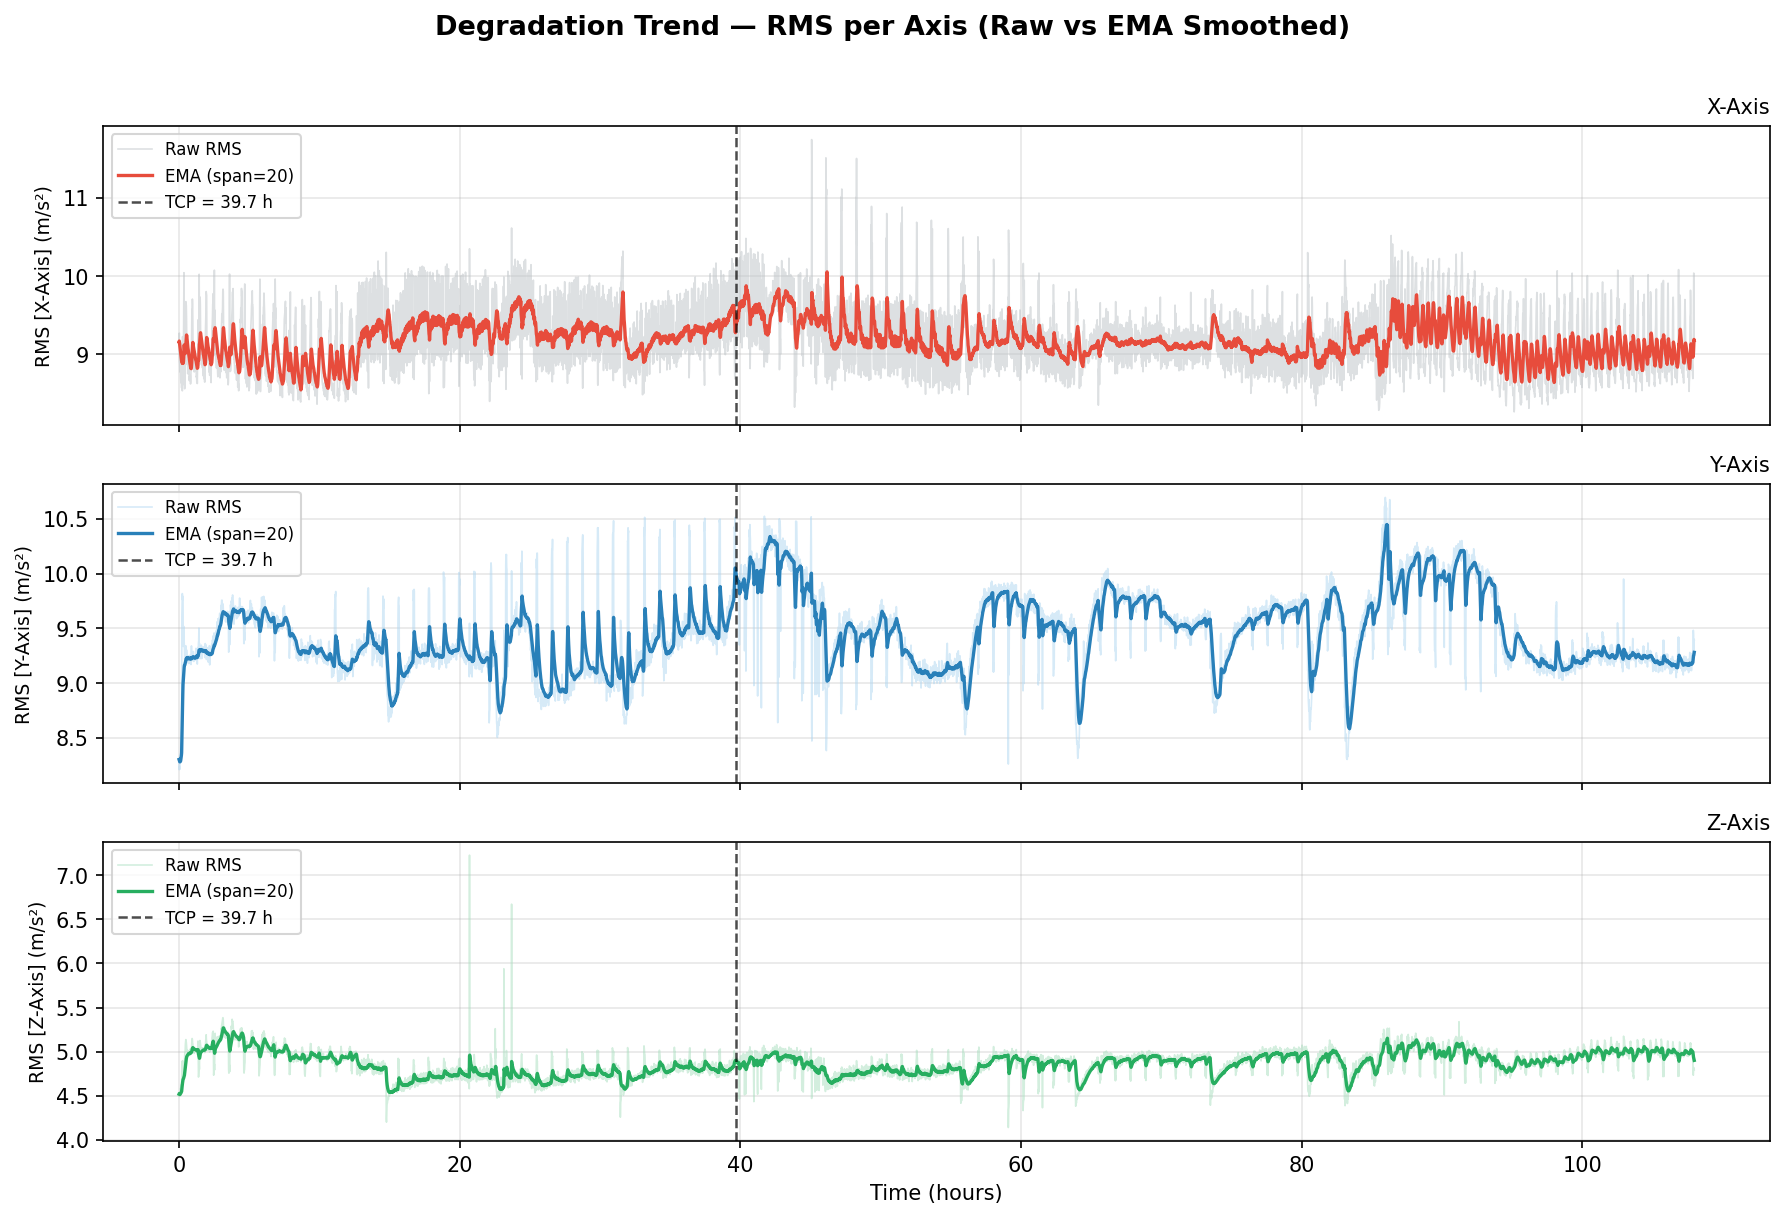

In [12]:
colors_raw    = ['#BDC3C7', '#AED6F1', '#A9DFBF']
colors_smooth = ['#E74C3C', '#2980B9', '#27AE60']
labels_ax     = ['X-Axis', 'Y-Axis', 'Z-Axis']
t_axis        = df_features['time_min'].values / 60   # hours

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Degradation Trend — RMS per Axis (Raw vs EMA Smoothed)', fontsize=13, fontweight='bold', y=1.01)

for i, ax_label in enumerate(AXES):
    ax = axes[i]
    raw_col   = f"td_rms_{ax_label}"
    smooth_col = f"rms_ema_{ax_label}"

    ax.plot(t_axis, df_features[raw_col], color=colors_raw[i], alpha=0.5, lw=0.8, label='Raw RMS')
    ax.plot(t_axis, df_features[smooth_col], color=colors_smooth[i], lw=1.6, label=f'EMA (span={EMA_SPAN})')
    ax.axvline(T_cp_min / 60, color='black', ls='--', lw=1.2, alpha=0.7, label=f'TCP = {T_cp_min/60:.1f} h')
    ax.set_ylabel(f'RMS [{labels_ax[i]}] (m/s²)', fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title(labels_ax[i], fontsize=10, loc='right')

axes[-1].set_xlabel('Time (hours)', fontsize=10)
plt.tight_layout()
plt.savefig('plot1_degradation_trend.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 2 — CUSUM Chart on Selected Axis with TCP Annotation

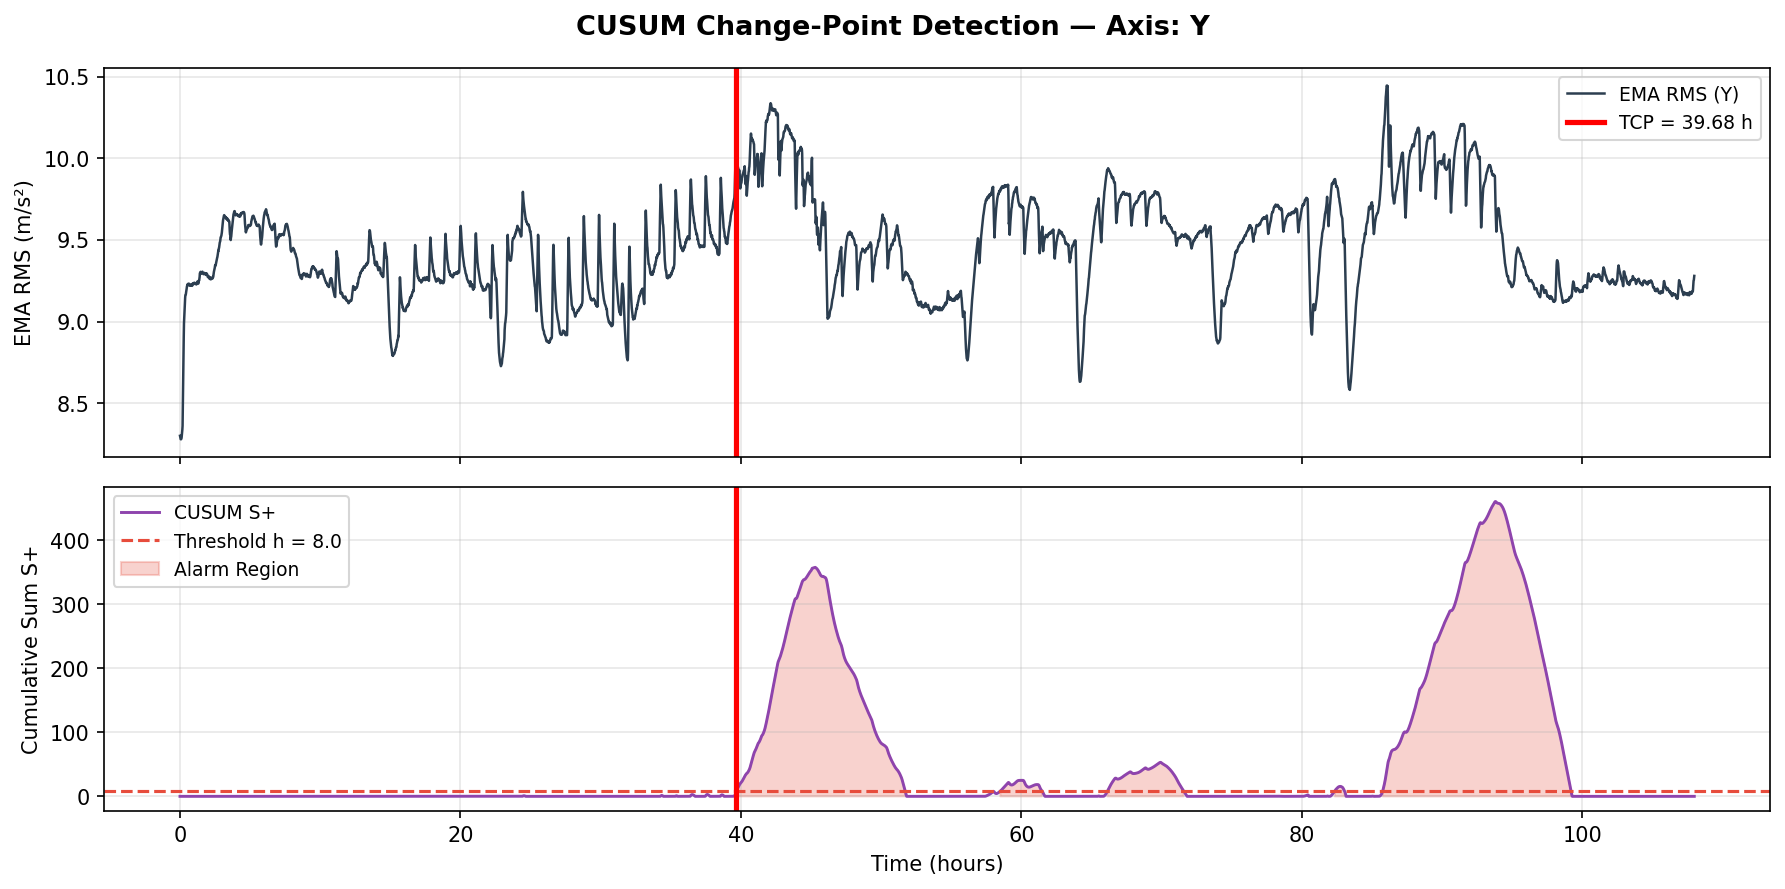

In [13]:
fig, axes_plt = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
fig.suptitle(f'CUSUM Change-Point Detection — Axis: {TARGET_TCP_AXIS.upper()}', fontsize=13, fontweight='bold')

# Top panel: smoothed RMS
axes_plt[0].plot(t_axis, df_features[cusum_col], color='#2C3E50', lw=1.2, label=f'EMA RMS ({TARGET_TCP_AXIS.upper()})')
axes_plt[0].axvline(T_cp_min / 60, color='red', lw=2.5, ls='-', label=f'TCP = {T_cp_min/60:.2f} h')
axes_plt[0].set_ylabel('EMA RMS (m/s²)')
axes_plt[0].legend()

# Bottom panel: CUSUM statistic
axes_plt[1].plot(t_axis, S_cusum, color='#8E44AD', lw=1.4, label='CUSUM S+')
axes_plt[1].axhline(CUSUM_H, color='#E74C3C', ls='--', lw=1.5, label=f'Threshold h = {CUSUM_H}')
axes_plt[1].axvline(T_cp_min / 60, color='red', lw=2.5, ls='-')
axes_plt[1].fill_between(t_axis, 0, S_cusum, where=(S_cusum > CUSUM_H), color='#E74C3C', alpha=0.25, label='Alarm Region')
axes_plt[1].set_ylabel('Cumulative Sum S+')
axes_plt[1].set_xlabel('Time (hours)')
axes_plt[1].legend()

plt.tight_layout()
plt.savefig('plot2_cusum.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 3 — BHI Label Curve

oi


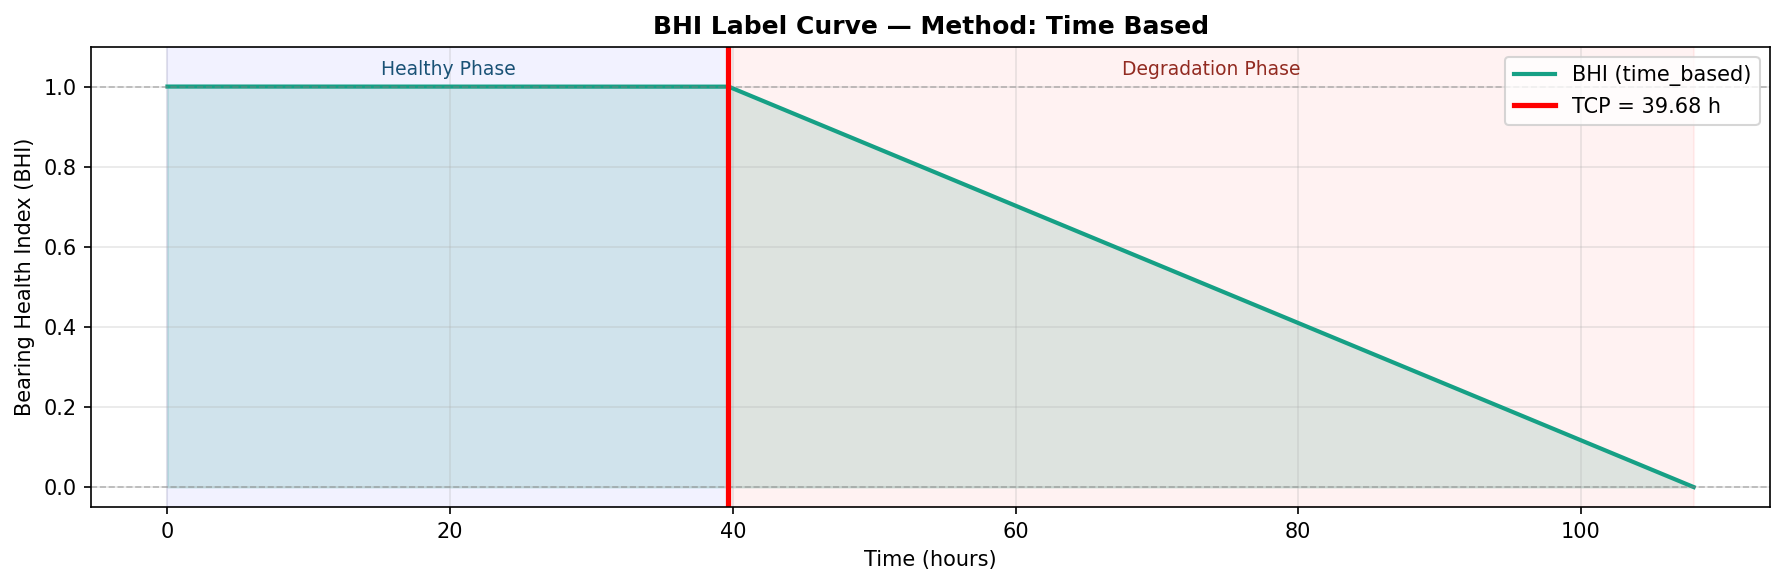

In [14]:
### Plot 3 — BHI Label Curve
fig, ax = plt.subplots(figsize=(12, 4))

# Plot BHI curve
ax.plot(t_axis, bhi, color='#16A085', lw=2, label=f'BHI ({BHI_METHOD})')
ax.fill_between(t_axis, 0, bhi, alpha=0.15, color='#16A085')

# Horizontal reference lines
ax.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axhline(0.0, color='gray', lw=0.8, ls='--', alpha=0.5)

# Only show TCP line if using time-based method
if BHI_METHOD == 'time_based':
    print("oi") 
    ax.axvline(T_cp_min / 60, color='red', lw=2.5, ls='-', label=f'TCP = {T_cp_min/60:.2f} h')
    ax.set_ylim(-0.05, 1.10)
    
    # Annotate phases for time-based
    tcp_h = T_cp_min / 60
    ax.annotate('Healthy Phase', xy=(tcp_h / 2, 1.03), ha='center', fontsize=9, color='#1A5276')
    ax.annotate('Degradation Phase', xy=((tcp_h + t_axis[-1]) / 2, 1.03), ha='center', fontsize=9, color='#922B21')
    ax.axvspan(0, tcp_h, alpha=0.05, color='blue')
    ax.axvspan(tcp_h, t_axis[-1], alpha=0.05, color='red')
else:
    # For signal-based: no distinct phases, continuous degradation
    ax.set_ylim(-0.05, 1.05)
    
    # Find approximate midpoint for annotation
    mid_idx = len(t_axis) // 2
    ax.annotate('Early Stage', xy=(t_axis[mid_idx]/2, 0.90), ha='center', fontsize=9, color='#1A5276')
    ax.annotate('Advanced Stage', xy=(t_axis[mid_idx]*1.5, 0.30), ha='center', fontsize=9, color='#922B21')

ax.set_xlabel('Time (hours)', fontsize=10)
ax.set_ylabel('Bearing Health Index (BHI)', fontsize=10)
ax.set_title(f'BHI Label Curve — Method: {BHI_METHOD.replace("_", " ").title()}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('plot3_bhi_curve.png', dpi=200, bbox_inches='tight')
plt.show()

### Plot 4 — Frequency Spectrum: Healthy vs Faulty Sample with BPFI Annotation

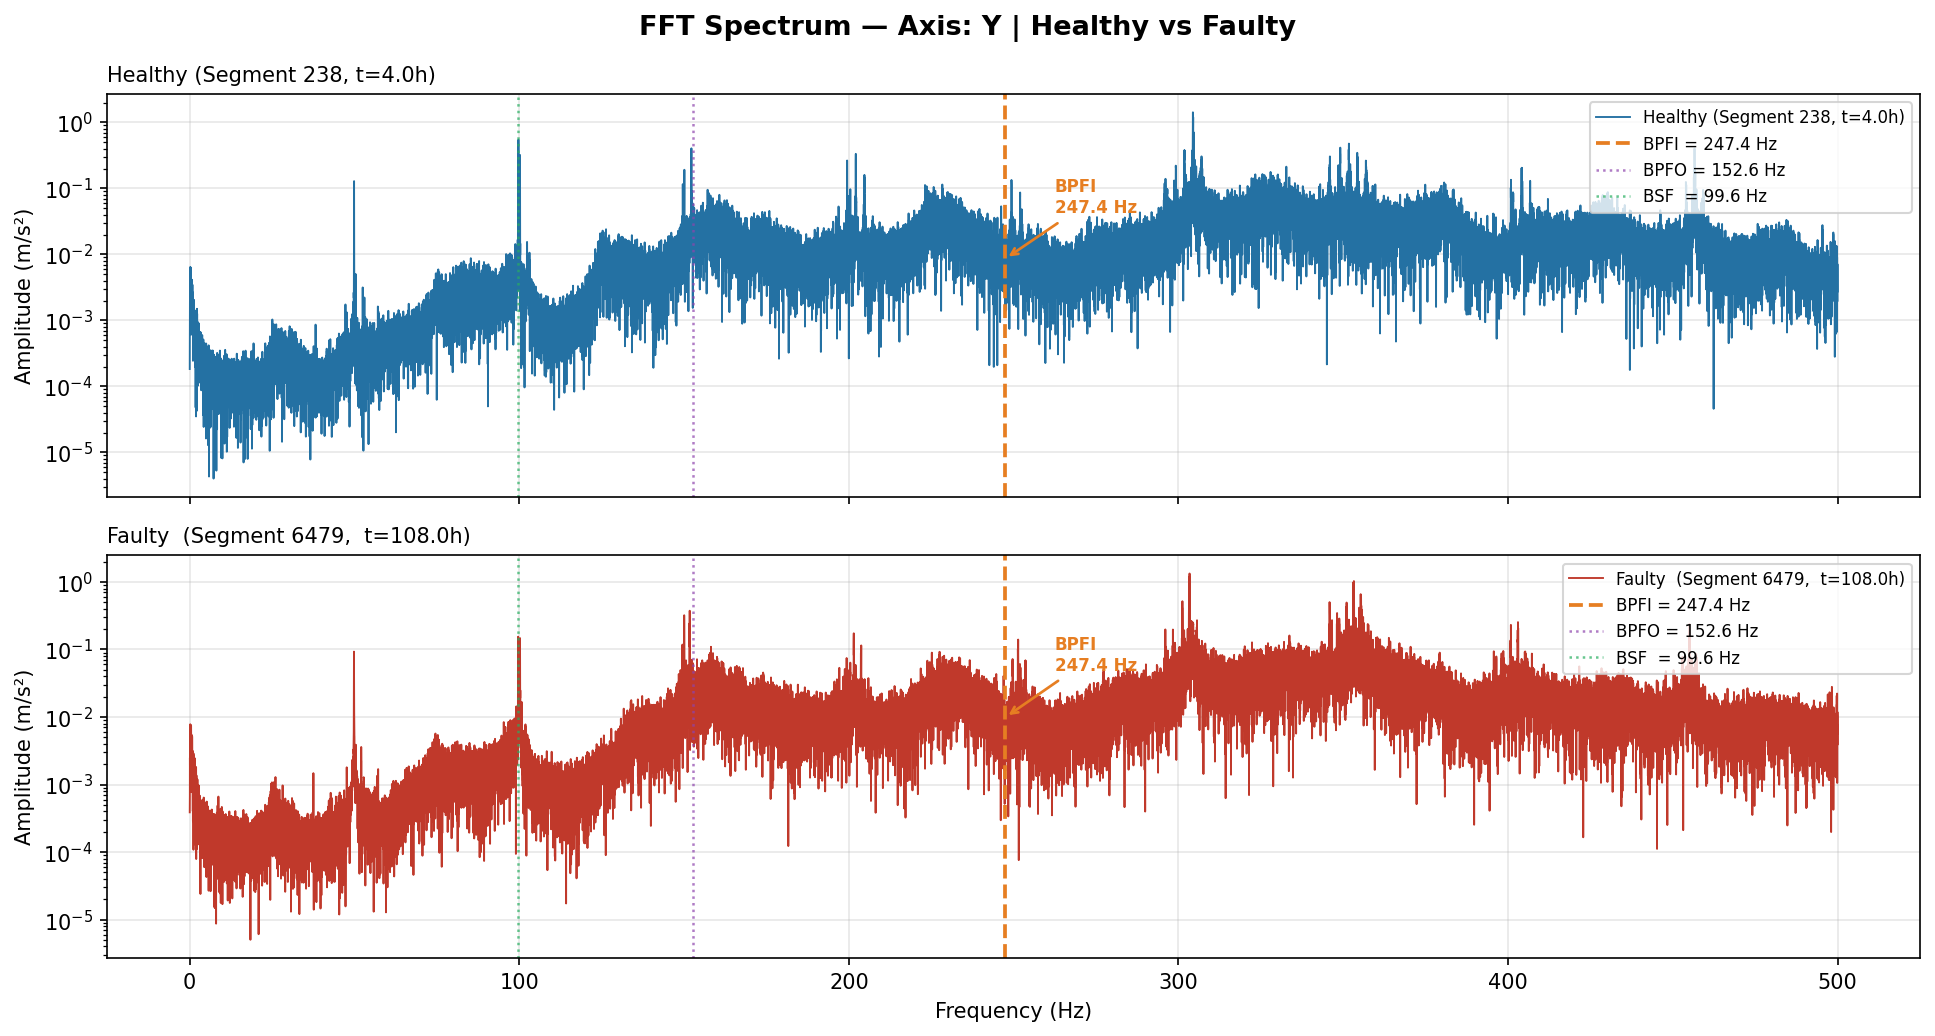

In [15]:
healthy_idx = int(T_cp_segment * 0.1)
faulty_idx  = N_SEGMENTS - 1

axis_idx_map = {"x": 0, "y": 1, "z": 2}
a_idx = axis_idx_map[TARGET_TCP_AXIS]

def get_segment_axis(seg_idx, a_index):
    """Read a single segment from the raw parquet using pyarrow dataset (no polars)."""
    col_name = target_cols[a_index]
    offset   = seg_idx * SAMPLES_PER_SEG
    scanner  = dataset.scanner(columns=[col_name])
    tbl      = scanner.to_table()
    chunk    = tbl.slice(offset, SAMPLES_PER_SEG).to_pandas().values[:, 0]
    return chunk.astype(np.float64)

seg_healthy = get_segment_axis(healthy_idx, a_idx)
seg_faulty  = get_segment_axis(faulty_idx,  a_idx)

fft_h = np.abs(np.fft.rfft(seg_healthy)) * 2 / SAMPLES_PER_SEG
fft_f = np.abs(np.fft.rfft(seg_faulty))  * 2 / SAMPLES_PER_SEG
freqs = np.fft.rfftfreq(SAMPLES_PER_SEG, d=1.0 / SAMPLING_RATE)

freq_mask = freqs <= 500

fig, axes_spec = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle(
    f"FFT Spectrum — Axis: {TARGET_TCP_AXIS.upper()} | Healthy vs Faulty",
    fontsize=13, fontweight="bold"
)

panel_data = [
    (fft_h, f"Healthy (Segment {healthy_idx}, t={healthy_idx*SEGMENT_SECONDS/3600:.1f}h)", "#2471A3"),
    (fft_f, f"Faulty  (Segment {faulty_idx},  t={faulty_idx*SEGMENT_SECONDS/3600:.1f}h)",  "#C0392B"),
]

for ax, (fft_data, label, color) in zip(axes_spec, panel_data):
    ax.semilogy(freqs[freq_mask], fft_data[freq_mask] + 1e-10, color=color, lw=0.9, label=label)

    ax.axvline(BPFI, color="#E67E22", lw=1.8, ls="--", label=f"BPFI = {BPFI:.1f} Hz")
    ax.axvline(BPFO, color="#8E44AD", lw=1.2, ls=":",  alpha=0.7, label=f"BPFO = {BPFO:.1f} Hz")
    ax.axvline(BSF,  color="#27AE60", lw=1.2, ls=":",  alpha=0.7, label=f"BSF  = {BSF:.1f} Hz")

    bpfi_amp = np.interp(BPFI, freqs, fft_data)
    ax.annotate(
        f"BPFI\n{BPFI:.1f} Hz", xy=(BPFI, bpfi_amp),
        xytext=(BPFI + 15, bpfi_amp * 5),
        arrowprops=dict(arrowstyle="->", color="#E67E22", lw=1.3),
        fontsize=8, color="#E67E22", fontweight="bold"
    )

    ax.set_ylabel("Amplitude (m/s²)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(label, fontsize=10, loc="left")

axes_spec[-1].set_xlabel("Frequency (Hz)", fontsize=10)
plt.tight_layout()
plt.savefig("plot4_fft_spectrum.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Save Unscaled

In [16]:
os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)


meta_cols = ['segment', 'time_s', 'time_min', 'bhi', 'label_vcd', 'T_cp', 'T_f']
ema_cols  = [c for c in df_features.columns if c.startswith('rms_ema_')]
feat_cols = [c for c in df_features.columns if c not in meta_cols + ema_cols]

output_path = os.path.join(OUTPUT_PARQUET, "processed_bearing1.parquet")
os.makedirs(OUTPUT_PARQUET, exist_ok=True)
df_features.to_parquet(output_path, engine='pyarrow', index=False)
print(f"Saved (unscaled): {output_path} | Shape: {df_features.shape}")

Saved (unscaled): D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1\processed_bearing1.parquet\processed_bearing1.parquet | Shape: (6480, 61)


## 10. Summary Report

In [17]:
print("=" * 60)
print("PREPROCESSING SUMMARY — BEARING-1")
print("=" * 60)
print(f"Total raw samples processed : {N_SEGMENTS * SAMPLES_PER_SEG:,}")
print(f"Segments extracted          : {N_SEGMENTS}")
print(f"Segment length              : {SEGMENT_SECONDS} s ({SAMPLES_PER_SEG:,} samples)")
print(f"Total features (per segment): {len(feat_cols)}")
print("")
print(f"Bearing defect frequencies:")
print(f"  BPFO  = {BPFO:.2f} Hz")
print(f"  BPFI  = {BPFI:.2f} Hz")
print(f"  BSF   = {BSF:.2f} Hz")
print("")
print(f"CUSUM target axis  : {TARGET_TCP_AXIS.upper()}")
print(f"TCP segment index  : {T_cp_segment}  ({T_cp_min:.1f} min / {T_cp_min/60:.2f} h)")
print(f"Degradation type   : {DEGRADATION_TYPE}")
print(f"BHI range          : [{bhi.min():.4f}, {bhi.max():.4f}]")
print("")
print(f"Output file        : {OUTPUT_PARQUET}")
print("=" * 60)

PREPROCESSING SUMMARY — BEARING-1
Total raw samples processed : 995,328,000
Segments extracted          : 6480
Segment length              : 60 s (153,600 samples)
Total features (per segment): 54

Bearing defect frequencies:
  BPFO  = 152.60 Hz
  BPFI  = 247.40 Hz
  BSF   = 99.55 Hz

CUSUM target axis  : Y
TCP segment index  : 2381  (2381.0 min / 39.68 h)
Degradation type   : linear
BHI range          : [0.0000, 1.0000]

Output file        : D:\ProyekDosen\Riset Bearing ShaftMissalignment + XAI\bearing_1\processed_bearing1.parquet
